<a href="https://colab.research.google.com/github/stephanieabisaab/final_exam_abi_saab/blob/main/lab3_part1_abi_saab_stephanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:

# INSTALL
!pip install wordcloud matplotlib numpy pandas scikit-learn datasets seaborn nltk -q

# IMPORTs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from datasets import load_dataset
import seaborn as sns

print("SETUP OK")

# LOAD DATASET

dataset = load_dataset("SetFit/20_newsgroups")
df = pd.DataFrame(dataset["train"])

print("DATA:", df.shape)

# CHOOSE CATEGORIES
my_categories = ["sci.space", "rec.sport.hockey", "talk.politics.guns"]

df = df[df["label_text"].isin(my_categories)].reset_index(drop=True)

print(df["label_text"].value_counts())


# CLEAN TEXT
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean(text):
    text = text.lower()
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    # FIX: NO nltk tokenizer (prevents crash)
    tokens = text.split()

    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

df["clean"] = df["text"].apply(clean)

print("CLEAN DONE")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


SETUP OK


Repo card metadata block was not found. Setting CardData to empty.


DATA: (11314, 3)
label_text
rec.sport.hockey      600
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64
CLEAN DONE


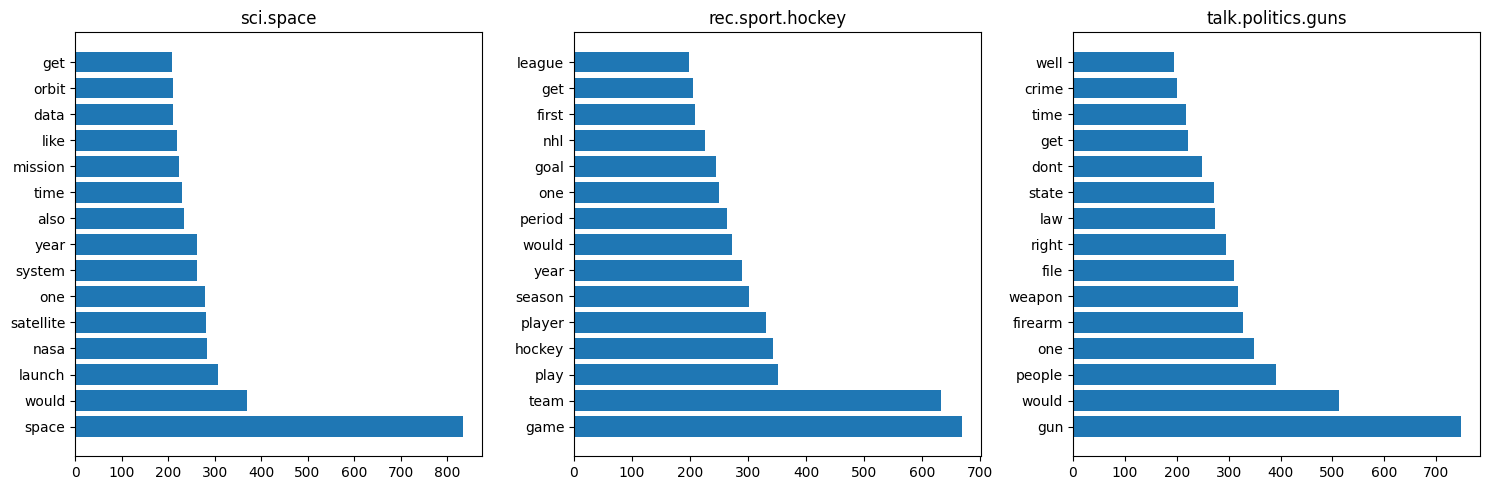

In [7]:


# TOP WORDS

def top_words(texts):
    return Counter(" ".join(texts).split()).most_common(15)

plt.figure(figsize=(15,5))

for i, cat in enumerate(my_categories):
    texts = df[df["label_text"] == cat]["clean"]
    words = top_words(texts)
    w, c = zip(*words)

    plt.subplot(1,3,i+1)
    plt.barh(w, c)
    plt.title(cat)

plt.tight_layout()
plt.show()




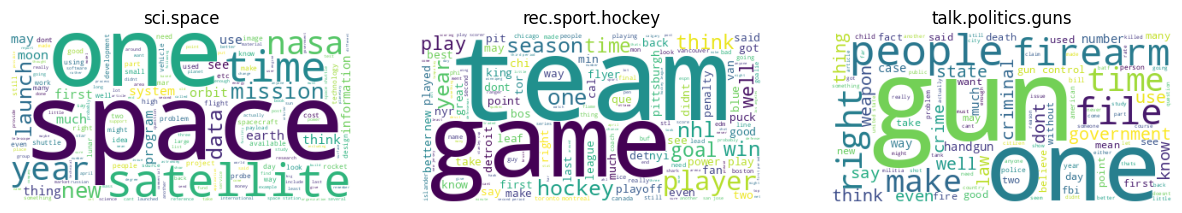

In [8]:

# WORD CLOUDS
plt.figure(figsize=(15,5))

for i, cat in enumerate(my_categories):
    text = " ".join(df[df["label_text"] == cat]["clean"])
    wc = WordCloud(background_color="white").generate(text)

    plt.subplot(1,3,i+1)
    plt.imshow(wc)
    plt.axis("off")
    plt.title(cat)

plt.show()

In [9]:

# BAG OF WORDS
bow = CountVectorizer(max_features=1000, min_df=5, max_df=0.95)
X = bow.fit_transform(df["clean"])

print("BoW shape:", X.shape)

BoW shape: (1739, 1000)


In [10]:
# SIMILARITY

sim = cosine_similarity(X)
np.fill_diagonal(sim, 0)

i, j = np.unravel_index(np.argmax(sim), sim.shape)

print("Most similar docs:", i, j)
print("Score:", sim[i, j])

Most similar docs: 474 591
Score: 1.0


In [11]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.95)
T = tfidf.fit_transform(df["clean"])

def top_tfidf(cat):
    idx = df[df["label_text"] == cat].index
    mean = T[idx].mean(axis=0).A1
    words = tfidf.get_feature_names_out()

    top = mean.argsort()[::-1][:10]
    return [words[k] for k in top]

for c in my_categories:
    print("\n", c, top_tfidf(c))



 sci.space ['space', 'would', 'like', 'one', 'nasa', 'orbit', 'launch', 'get', 'could', 'moon']

 rec.sport.hockey ['game', 'team', 'player', 'hockey', 'play', 'year', 'season', 'would', 'nhl', 'playoff']

 talk.politics.guns ['gun', 'would', 'people', 'weapon', 'dont', 'right', 'law', 'one', 'government', 'firearm']


In [12]:

# BIGRAMS

bigram = CountVectorizer(ngram_range=(2,2), min_df=3)

for c in my_categories:
    texts = df[df["label_text"] == c]["clean"]
    Xb = bigram.fit_transform(texts)

    counts = np.array(Xb.sum(axis=0)).flatten()
    words = bigram.get_feature_names_out()

    top = counts.argsort()[::-1][:10]

    print("\n", c)
    for k in top:
        print(words[k], counts[k])



 sci.space
space station 69
space shuttle 56
anonymous ftp 37
commercial space 31
remote sensing 30
launch vehicle 27
national space 26
nasa ames 24
air force 23
space technology 21

 rec.sport.hockey
power play 138
play scorer 63
san jose 62
third period 58
second period 56
first period 53
los angeles 52
hockey league 52
new jersey 51
tampa bay 50

 talk.politics.guns
gun control 110
united state 72
second amendment 56
dont know 34
dont think 32
waiting period 32
bear arm 30
assault weapon 30
gun owner 29
law enforcement 29


In [13]:


# NEXT WORD MODEL

class Model:
    def __init__(self):
        self.bigram = {}

    def train(self, texts):
        for t in texts:
            w = t.split()
            for i in range(len(w)-1):
                a, b = w[i], w[i+1]
                if a not in self.bigram:
                    self.bigram[a] = {}
                self.bigram[a][b] = self.bigram[a].get(b, 0) + 1

    def predict(self, w):
        if w not in self.bigram:
            return []
        d = self.bigram[w]
        s = sum(d.values())
        return sorted([(k, v/s) for k, v in d.items()], key=lambda x: -x[1])[:5]

m = Model()
m.train(df["clean"])

for w in ["space", "game", "gun"]:
    print("\n", w, m.predict(w))



 space [('station', 0.08224076281287247), ('shuttle', 0.066746126340882), ('technology', 0.025029797377830752), ('program', 0.023837902264600714), ('science', 0.021454112038140644)]

 game [('played', 0.03268945022288262), ('point', 0.019316493313521546), ('pick', 0.017830609212481426), ('season', 0.01634472511144131), ('would', 0.014858841010401188)]

 gun [('control', 0.14285714285714285), ('owner', 0.03766233766233766), ('law', 0.02987012987012987), ('ownership', 0.023376623376623377), ('would', 0.016883116883116882)]


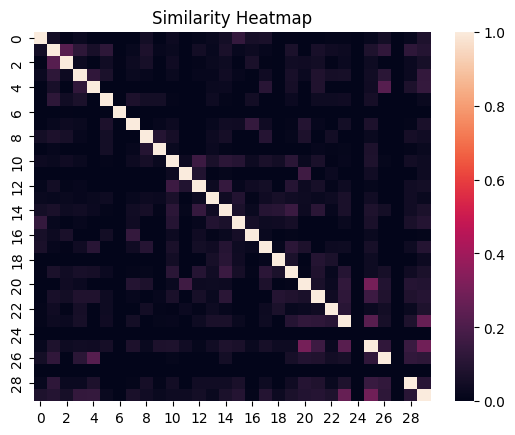

DONE


In [14]:

# HEATMAP

sample = []

for c in my_categories:
    sample.append(df[df["label_text"] == c].sample(10, random_state=42))

sample = pd.concat(sample)

T2 = TfidfVectorizer(max_features=500).fit_transform(sample["clean"])
S = cosine_similarity(T2)

sns.heatmap(S)
plt.title("Similarity Heatmap")
plt.show()

print("DONE")